# California Flight Delays in 2024

## Install Dependency to Import from Kaggle

In [4]:
!pip install opendatasets

In [5]:
import opendatasets as od

od.download("https://www.kaggle.com/datasets/hrishitpatil/flight-data-2024/")

## Read in `flight_data_2024.csv`

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/content/flight-data-2024/flight_data_2024.csv")

## Filter dataframe by `California` with 50K sample and export to CSV

In [7]:
filtered_df = df[df['origin_state_nm'] == "California"].sample(50000,random_state=42)


filtered_df = filtered_df[['year', 'month', 'day_of_month', 'day_of_week', 'op_unique_carrier', 'dep_time', 'dep_delay', 'arr_time', 'arr_delay', 'air_time', 'distance', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']]
filtered_df = filtered_df.reset_index(drop=True)
filtered_df.to_csv('california_flights_50k_sample.csv')

filtered_df.info()

# Filtered 50K California sample: https://raw.githubusercontent.com/sjsu-cs133-s26/team5-flightdelay-transportation/refs/heads/main/data/california_flights_50k_sample.csv

In [27]:
df_california = pd.read_csv('https://raw.githubusercontent.com/sjsu-cs133-s26/team5-flightdelay-transportation/refs/heads/main/data/california_flights_50k_sample.csv', index_col=0)

df_california

,year,month,day_of_month,day_of_week,op_unique_carrier,dep_time,dep_delay,arr_time,arr_delay,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,9,10,2,WN,1445.0,-5.0,1927.0,-23.0,149.0,1232.0,0,0,0,0,0
1,2024,4,4,4,AA,1523.0,-7.0,2334.0,-25.0,290.0,2475.0,0,0,0,0,0
2,2024,6,29,6,AA,1644.0,8.0,2146.0,2.0,155.0,1171.0,0,0,0,0,0
3,2024,6,14,5,WN,1308.0,43.0,2121.0,56.0,272.0,2329.0,43,0,13,0,0
4,2024,12,13,5,UA,1047.0,-3.0,1403.0,-12.0,113.0,909.0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2024,8,29,4,WN,2011.0,16.0,2116.0,-4.0,48.0,304.0,0,0,0,0,0
49996,2024,10,1,2,AA,1536.0,-8.0,1743.0,-1.0,95.0,651.0,0,0,0,0,0
49997,2024,1,1,1,WN,729.0,-6.0,848.0,-17.0,61.0,358.0,0,0,0,0,0
49998,2024,10,29,2,DL,1043.0,-8.0,1528.0,-26.0,144.0,1242.0,0,0,0,0,0


In [28]:
#Show amount of NaN values for each column
# df_california = df_california.dropna()

df_california.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 50000 non-null  int64  
 1   month                50000 non-null  int64  
 2   day_of_month         50000 non-null  int64  
 3   day_of_week          50000 non-null  int64  
 4   op_unique_carrier    50000 non-null  object 
 5   dep_time             49511 non-null  float64
 6   dep_delay            49510 non-null  float64
 7   arr_time             49472 non-null  float64
 8   arr_delay            49371 non-null  float64
 9   air_time             49371 non-null  float64
 10  distance             50000 non-null  float64
 11  carrier_delay        50000 non-null  int64  
 12  weather_delay        50000 non-null  int64  
 13  nas_delay            50000 non-null  int64  
 14  security_delay       50000 non-null  int64  
 15  late_aircraft_delay  50000 non-null  int6

## Convert `op_unique_carrier` (airline code) to full Airline name and add to new column

In [10]:
# Translate Carrier Code to Airline
def airline(x):
  if x == "AA":
    return "American Airlines"
  elif x == "AS":
    return "Alaska Airlines"
  elif x == "B6":
    return "JetBlue Airways"
  elif x == "DL":
    return "Delta Airlines"
  elif x == "F9":
    return "Frontier Airlines"
  elif x == "G4":
    return "Allegiant Air"
  elif x == "HA":
    return "Hawaiian Airlines"
  elif x == "MQ":
    return "Envoy Air"
  elif x == "NK":
    return "Spirit Airlines"
  elif x == "OO":
    return "SkyWest Airlines"
  elif x == "UA":
    return "United Airlines"
  elif x == "WN":
    return "Southwest Airlines"

df_california["Airline"] = df_california['op_unique_carrier'].apply(airline)

df_california


/tmp/ipykernel_38910/3960813330.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_california["Airline"] = df_california['op_unique_carrier'].apply(airline)


,year,month,day_of_month,day_of_week,op_unique_carrier,dep_time,dep_delay,arr_time,arr_delay,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,Airline
0,2024,9,10,2,WN,1445.0,-5.0,1927.0,-23.0,149.0,1232.0,0,0,0,0,0,Southwest Airlines
1,2024,4,4,4,AA,1523.0,-7.0,2334.0,-25.0,290.0,2475.0,0,0,0,0,0,American Airlines
2,2024,6,29,6,AA,1644.0,8.0,2146.0,2.0,155.0,1171.0,0,0,0,0,0,American Airlines
3,2024,6,14,5,WN,1308.0,43.0,2121.0,56.0,272.0,2329.0,43,0,13,0,0,Southwest Airlines
4,2024,12,13,5,UA,1047.0,-3.0,1403.0,-12.0,113.0,909.0,0,0,0,0,0,United Airlines
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2024,8,29,4,WN,2011.0,16.0,2116.0,-4.0,48.0,304.0,0,0,0,0,0,Southwest Airlines
49996,2024,10,1,2,AA,1536.0,-8.0,1743.0,-1.0,95.0,651.0,0,0,0,0,0,American Airlines
49997,2024,1,1,1,WN,729.0,-6.0,848.0,-17.0,61.0,358.0,0,0,0,0,0,Southwest Airlines
49998,2024,10,29,2,DL,1043.0,-8.0,1528.0,-26.0,144.0,1242.0,0,0,0,0,0,Delta Airlines


In [11]:
df_california["op_unique_carrier"].unique()

array(['WN', 'AA', 'UA', 'OO', 'HA', 'AS', 'B6', 'DL', 'G4', 'F9', 'NK',
       'MQ'], dtype=object)

Observe distribution

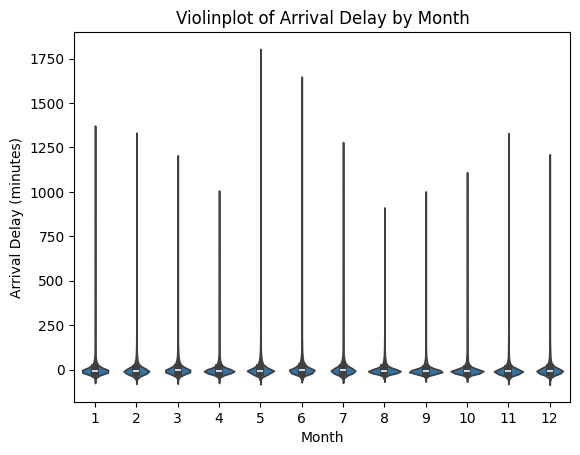

In [12]:
plot_data = df_california.groupby('month')['arr_delay'].apply(list).reset_index()
plot_data = plot_data.explode("arr_delay").reset_index(drop=True)
sns.violinplot(data=plot_data, x='month', y='arr_delay')
plt.xlabel("Month")
plt.ylabel("Arrival Delay (minutes)")
plt.title("Violinplot of Arrival Delay by Month");

After Removing outlier points

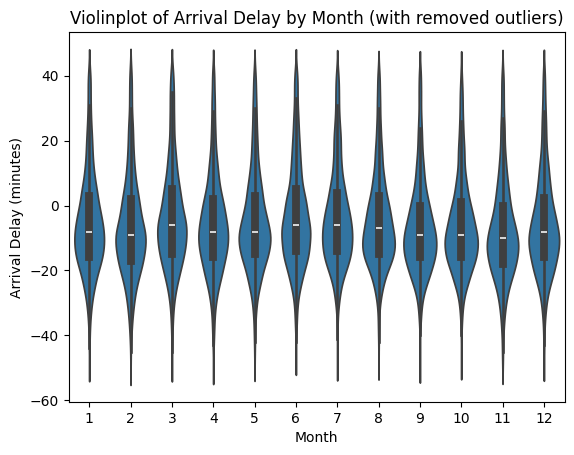

In [13]:
q1 = plot_data['arr_delay'].quantile(0.25)
q3 = plot_data['arr_delay'].quantile(0.75)
iqr = q3-q1
lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr
plot_data = plot_data[(plot_data['arr_delay'] >= lower_bound) &(plot_data['arr_delay'] <= upper_bound)]
sns.violinplot(data=plot_data, x='month', y='arr_delay')
plt.xlabel("Month")
plt.ylabel("Arrival Delay (minutes)")
plt.title("Violinplot of Arrival Delay by Month (with removed outliers)");

## Average Arrival Delay by Departure Hour (categorical bar plot)
Data includes on-time and early flights

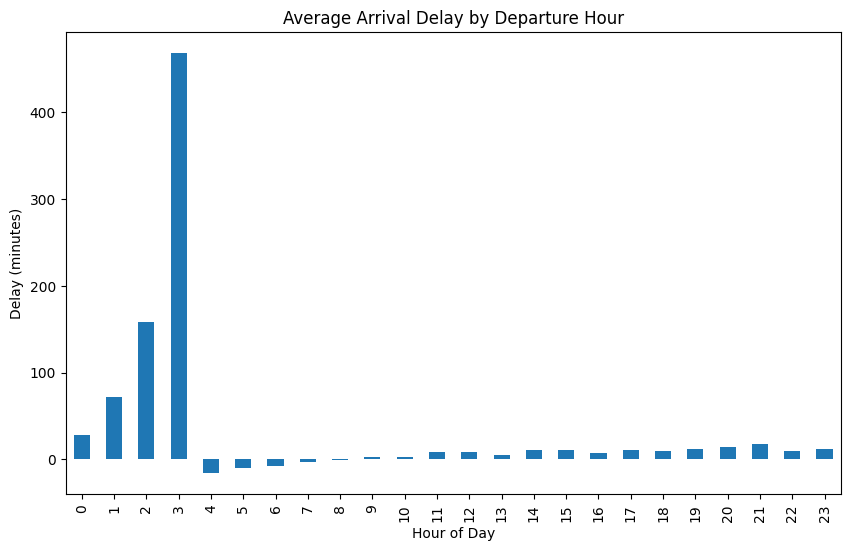

In [14]:
df_time = df_california[df_california['dep_time'].notna()]

df_time['dep_hour'] = (df_time['dep_time'] // 100).astype(int)

df_time.loc[df_time['dep_hour'] == 24, 'dep_hour'] = 0

avg_delay = df_time.groupby('dep_hour')['arr_delay'].mean()

avg_delay.plot(kind='bar', figsize=(10,6))
plt.title("Average Arrival Delay by Departure Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Delay (minutes)")
plt.show()

## Relationship between Distance and Air Time (small-multiples relplot)

In [15]:
def delay_time(x):
    if x < 0:
        return "Early"
    elif x==0:
        return "On time"
    elif 0< x < 15:
        return "Slightly Late (<15mins)"
    elif 15<x<60:
        return "Late (<60mins)"
    else:
        return "Very late (>60 mins)"
#this is based on arrival delay ONLY.
df_california["Late_status"]=df_california["arr_delay"].apply(delay_time)

/tmp/ipykernel_38910/1219358625.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_california["Late_status"]=df_california["arr_delay"].apply(delay_time)


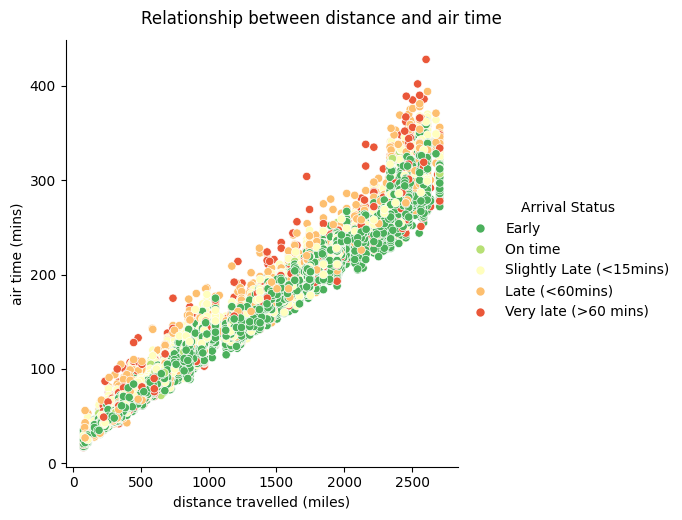

In [16]:

hue_order = ["Early", "On time","Slightly Late (<15mins)", "Late (<60mins)", "Very late (>60 mins)"]
p=sns.relplot(data=df_california,
            x="distance",
            y="air_time",
            hue="Late_status",
            hue_order=hue_order,
            palette="RdYlGn_r")

p.set_axis_labels("distance travelled (miles)", "air time (mins)")
p.fig.suptitle("Relationship between distance and air time", y=1.03)
p.legend.set_title("Arrival Status")
plt.show()

## Calculate Average Delay by Airline

Calculate the average arrival delay for each airline in the `df_california` DataFrame.


In [17]:
avg_delay_by_airline = df_california.groupby('Airline')['arr_delay'].mean()
avg_delay_by_airline



,arr_delay
Airline,
Alaska Airlines,4.374584
Allegiant Air,15.427536
American Airlines,12.803546
Delta Airlines,4.124098
Envoy Air,-0.921788
Frontier Airlines,21.680189
Hawaiian Airlines,7.714286
JetBlue Airways,2.117860
SkyWest Airlines,6.474277


## Plot Average Delay by Airline
Data includes on-time and early flights




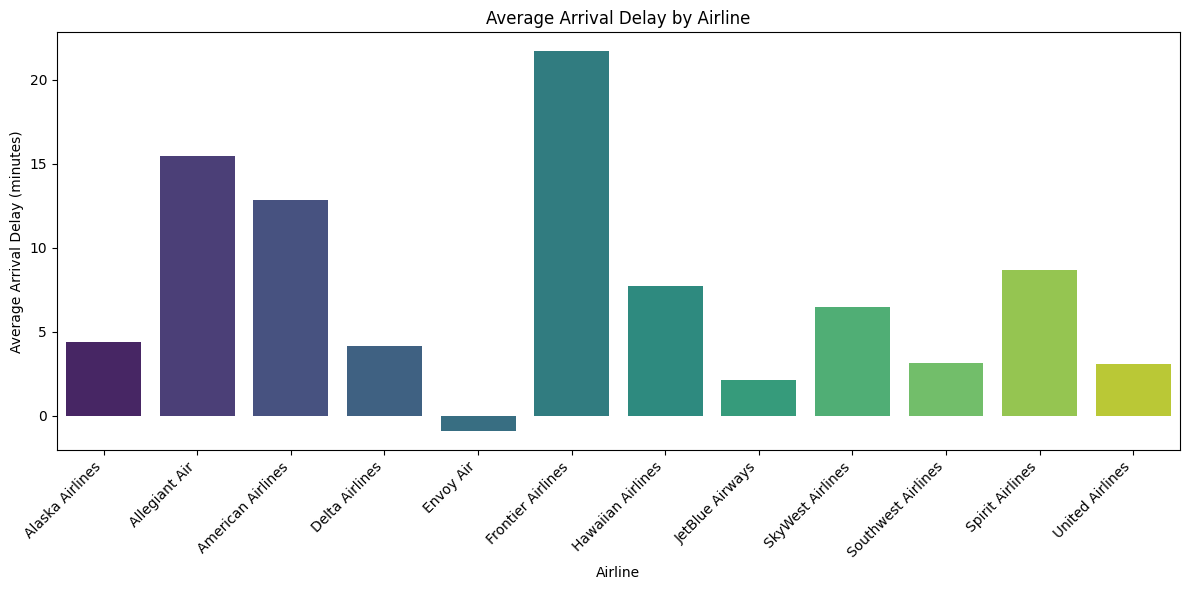

In [18]:
plt.figure(figsize=(12, 6))
sns.barplot(x=avg_delay_by_airline.index, y=avg_delay_by_airline.values, hue=avg_delay_by_airline.index, palette='viridis', legend=False)
plt.title('Average Arrival Delay by Airline')
plt.xlabel('Airline')
plt.ylabel('Average Arrival Delay (minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Count number of flights per airline


In [19]:
df_california['Airline'].value_counts()

,count
Airline,
Southwest Airlines,15226
SkyWest Airlines,9505
United Airlines,7052
American Airlines,4963
Delta Airlines,4851
Alaska Airlines,3006
Spirit Airlines,1674
JetBlue Airways,1103
Frontier Airlines,1060


# Project Assignment 3 Section

# Average Delay by Cause (new visualization)
Data includes on-time and early flights

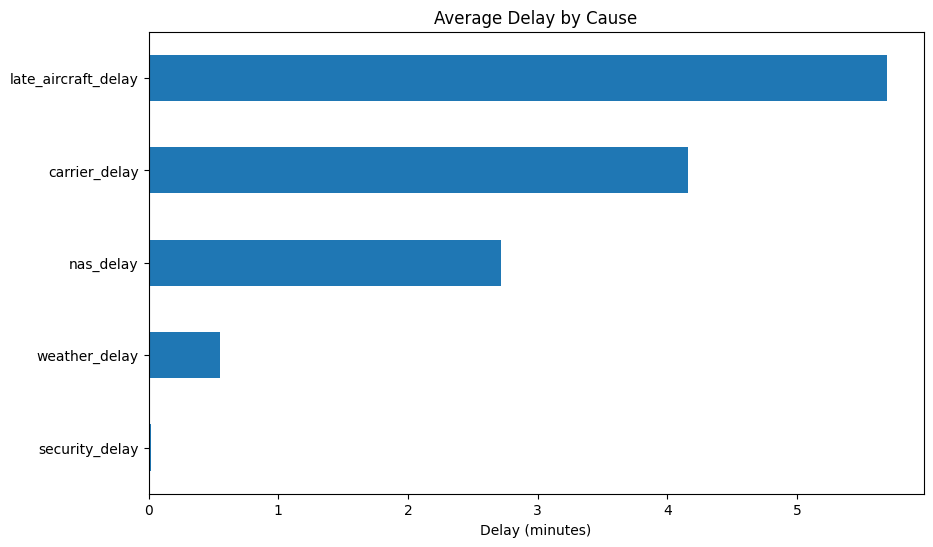

In [20]:
delay_causes = df_california[
    ['carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']
].mean().sort_values()

delay_causes.plot(kind='barh', figsize=(10,6))
plt.title("Average Delay by Cause")
plt.xlabel("Delay (minutes)")
plt.show()

# Average Delay by Day (new visualization)

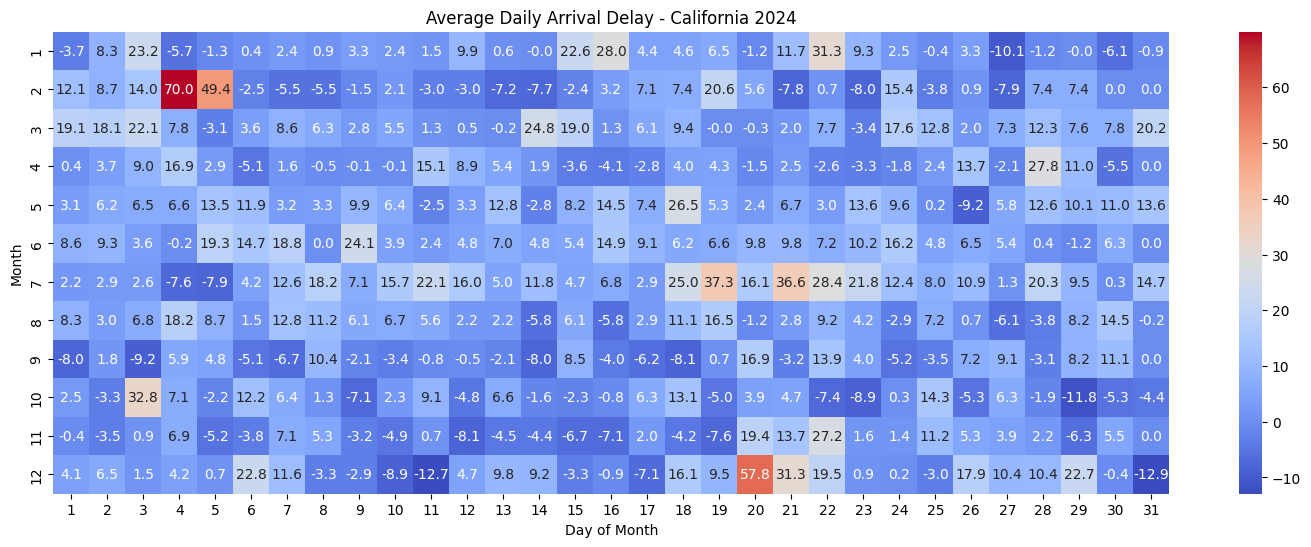

In [21]:
# make pivot table
heatmap_data = df_california.groupby(['month', 'day_of_month'])['arr_delay'].mean().unstack()

# fill missing dates
heatmap_data.fillna(0, inplace=True)

# heatmap
plt.figure(figsize=(18, 6))
plt.title("Average Daily Arrival Delay - California 2024")

sns.heatmap(data=heatmap_data,
            annot=True,
            fmt='.1f',
            cmap='coolwarm')

plt.xlabel("Day of Month")
plt.ylabel("Month")
plt.show()